In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  STAGE 0: DATA PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import IterableDataset, DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as scipy_signal
from sklearn.metrics import roc_auc_score, mean_absolute_error
import time
import math

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

FS          = 8192  # Strict George & Huerta sampling rate
DURATION    = 1.0
N_SAMPLES   = int(FS * DURATION)
N_DETECTORS = 3

def ligo_psd(freqs):
    S0, f0 = 1e-46, 150.0
    psd = np.zeros_like(freqs)
    m = freqs >= 20
    psd[m] = S0 * ((f0/freqs[m])**4 + 2*(1+(freqs[m]/f0)**2))
    return psd

def generate_colored_noise(n_samples, fs, rng):
    freqs = np.fft.rfftfreq(n_samples, d=1.0/fs)
    psd = ligo_psd(freqs)
    
    return np.fft.irfft(np.fft.rfft(rng.standard_normal(n_samples)) * np.sqrt(psd*fs/2), n=n_samples)

def generate_bbh_chirp(m1, m2, n_samples, fs, f_lower=20.0, snr_target=10.0):
    G, c, M_sun = 6.674e-11, 3e8, 1.989e30
    Mc = ((m1*m2)**0.6/(m1+m2)**0.2)*M_sun
    t_coal = min((5/256)*(G*Mc/c**3)**(-5/3)*(np.pi*f_lower)**(-8/3), 0.8*n_samples/fs)
    merger_s = int(0.80*n_samples)
    t = np.linspace(-merger_s/fs, (n_samples-merger_s)/fs, n_samples)
    t_insp = t[t < 0]
    tau = np.clip(t_coal + t_insp, 1e-4, None)
    f_inst = np.clip(f_lower*(tau/t_coal)**(-3/8), f_lower, fs/2-1)
    phase = -2*np.pi*np.cumsum(f_inst)/fs
    h = np.zeros(n_samples)
    h[:len(t_insp)] = (tau/t_coal)**(-1/4) * np.sin(phase)
    taper = np.hanning(128)[:64]
    h[:64] *= taper; h[merger_s:merger_s+64] *= taper[::-1]
    rms = np.sqrt(np.mean(h**2))
    return h/rms*snr_target*1e-21 if rms > 0 else h

def whiten(strain, fs):
    freqs = np.fft.rfftfreq(len(strain), d=1.0/fs)
    psd = ligo_psd(freqs)
    psd[psd == 0] = np.inf # Safely zero out dead frequencies
    w = np.fft.irfft(np.fft.rfft(strain)/np.sqrt(psd), n=len(strain))
    sos = scipy_signal.butter(6,[20,800],btype='bandpass',fs=fs,output='sos')
    return scipy_signal.sosfilt(sos, w)

class GWIterableDataset(IterableDataset):
    def __init__(self, samples_per_epoch, signal_fraction=0.5):
        super().__init__()
        self.n = samples_per_epoch
        self.sig = signal_fraction

    def __iter__(self):
        worker = torch.utils.data.get_worker_info()
        seed = int(time.time()*1e6) % (2**31)
        if worker is not None:
            seed += worker.id * 9999
            n_yield = math.ceil(self.n / worker.num_workers) 
        else:
            n_yield = self.n

        rng = np.random.default_rng(seed)
        for _ in range(n_yield):
            is_sig = rng.random() < self.sig
            noise = [generate_colored_noise(N_SAMPLES, FS, rng) for _ in range(N_DETECTORS)]
            X = np.zeros((N_DETECTORS, N_SAMPLES), dtype=np.float32)
            y_prm = np.zeros(2, dtype=np.float32)

            if is_sig:
                m1, m2 = sorted(rng.uniform(10,50,2), reverse=True)
                snr = rng.uniform(6, 20)
                chirp = generate_bbh_chirp(m1, m2, N_SAMPLES, FS, snr_target=snr)
                y_prm[:] = [m1, m2]
                for d in range(N_DETECTORS):
                    nf = 1.0 if d < 2 else 2.0
                    X[d] = whiten(noise[d]*nf + chirp, FS).astype(np.float32)
            else:
                for d in range(N_DETECTORS):
                    nf = 1.0 if d < 2 else 2.0
                    X[d] = whiten(noise[d]*nf, FS).astype(np.float32)

            yield torch.from_numpy(X), torch.tensor(int(is_sig), dtype=torch.long), torch.from_numpy(y_prm)

def make_static_test_set(n=1000, seed=42):
    print(f"Building static test set ({n} samples)...")
    rng = np.random.default_rng(seed)
    X = np.zeros((n, N_DETECTORS, N_SAMPLES), dtype=np.float32)
    ycls = np.zeros(n, dtype=np.int64)
    yprm = np.zeros((n,2), dtype=np.float32)
    for i in range(n):
        is_sig = i % 2 == 0
        noise = [generate_colored_noise(N_SAMPLES,FS,rng) for _ in range(N_DETECTORS)]
        if is_sig:
            m1,m2 = sorted(rng.uniform(10,50,2), reverse=True)
            snr = rng.uniform(6,20)
            chirp = generate_bbh_chirp(m1,m2,N_SAMPLES,FS,snr_target=snr)
            ycls[i]=1; yprm[i]=[m1,m2]
            for d in range(N_DETECTORS):
                nf = 1.0 if d<2 else 2.0
                X[i,d] = whiten(noise[d]*nf+chirp,FS).astype(np.float32)
        else:
            for d in range(N_DETECTORS):
                nf = 1.0 if d<2 else 2.0
                X[i,d] = whiten(noise[d]*nf,FS).astype(np.float32)
    return torch.from_numpy(X), torch.from_numpy(ycls), torch.from_numpy(yprm)

X_test, y_test_cls, y_test_prm = make_static_test_set()
test_loader = DataLoader(TensorDataset(X_test, y_test_cls, y_test_prm), batch_size=128, shuffle=False)
X_val, y_val_cls, y_val_prm = make_static_test_set(n=2000, seed=99) 

val_loader = DataLoader(
    TensorDataset(X_val, y_val_cls, y_val_prm),
    batch_size=128,
    shuffle=False
)

SAMPLES_PER_EPOCH = 5000
train_dataset = GWIterableDataset(samples_per_epoch=SAMPLES_PER_EPOCH)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    num_workers=2,
    pin_memory=True
)



Device: cuda
Building static test set (1000 samples)...
Building static test set (2000 samples)...



--- Training George & Huerta Exact CNN ---
CNN Ep  1/30 | train loss=0.4992 acc=0.948 | val loss=52.4545 acc=0.918 | reg_w=0.000 | 25s
CNN Ep  5/30 | train loss=0.0428 acc=1.000 | val loss=53.3856 acc=1.000 | reg_w=0.000 | 124s
CNN Ep 10/30 | train loss=2.7468 acc=1.000 | val loss=2.5596 acc=1.000 | reg_w=0.080 | 249s
CNN Ep 15/30 | train loss=2.9646 acc=1.000 | val loss=2.3719 acc=1.000 | reg_w=0.100 | 373s
CNN Ep 20/30 | train loss=2.8695 acc=1.000 | val loss=2.3125 acc=1.000 | reg_w=0.100 | 501s
CNN Ep 25/30 | train loss=2.6970 acc=1.000 | val loss=2.2985 acc=1.000 | reg_w=0.100 | 626s
CNN Ep 30/30 | train loss=2.7309 acc=1.000 | val loss=2.2871 acc=1.000 | reg_w=0.100 | 752s

CNN FINAL → AUC=1.0000 | MAE(m1)=6.05 | MAE(m2)=3.88 | 753s total


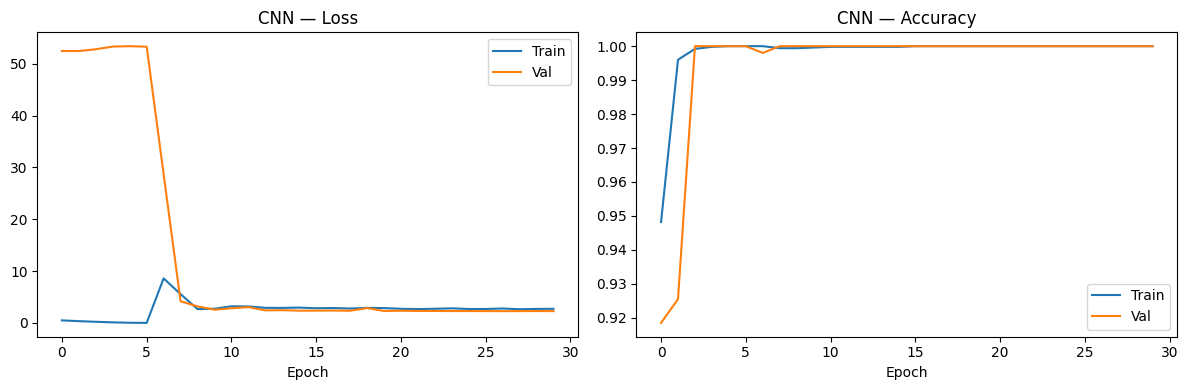

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  STAGE 2: GEORGE & HUERTA EXACT CNN & TRAINING
# ══════════════════════════════════════════════════════════════════════════════

class CNN(nn.Module):
    def __init__(self, n_det=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_det, 64, kernel_size=16, stride=1, padding=0),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=31, stride=1, padding=0),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(4),

            nn.Conv1d(128, 256, kernel_size=31, stride=1, padding=0),
            nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(4),

            nn.Conv1d(256, 512, kernel_size=63, stride=1, padding=0),
            nn.BatchNorm1d(512), nn.ReLU(), nn.MaxPool1d(4),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)

        self.dense = nn.Sequential(
            nn.Flatten(),          # (B, 512, 1) → (B, 512)
            nn.Linear(512, 128),   
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        self.cls_out = nn.Linear(64, 1)
        self.prm_out = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)           
        h = self.dense(x)
        return self.cls_out(h).squeeze(-1), self.prm_out(h)

def train_model(model, n_epochs=30, lr=1e-4, model_name="Model",
                warmup_cls_epochs=5, mask_fn=None, patience=8):

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    total_steps = n_epochs * math.ceil(SAMPLES_PER_EPOCH / 128)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.3, div_factor=10)

    history = {
        'train_loss':[], 'val_loss':[],
        'train_acc':[], 'val_acc':[]
    }

    
    best_val_loss = float('inf')
    counter = 0

    t0 = time.time()

    for epoch in range(n_epochs):

        # --- REGRESSION WARMUP ---
        if epoch < warmup_cls_epochs:
            reg_weight = 0.0
        else:
            ramp = min((epoch - warmup_cls_epochs) / max(warmup_cls_epochs, 1), 1.0)
            reg_weight = 0.1 * ramp

        # ================= TRAIN =================
        model.train()
        tot_loss = tot_acc = n = 0

        for xb, yc, yp in train_loader:
            xb, yc, yp = xb.to(DEVICE), yc.to(DEVICE).float(), yp.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)

            mask = mask_fn() if mask_fn else None
            cls_out, prm_out = model(xb, mask=mask) if mask is not None else model(xb)

            loss_cls = F.binary_cross_entropy_with_logits(cls_out, yc)
            loss_prm = F.mse_loss(prm_out, yp)
            loss = loss_cls + (reg_weight * loss_prm)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            preds = (cls_out.sigmoid() > 0.5).long()
            tot_acc += (preds == yc.long()).float().sum().item()
            tot_loss += loss.item() * len(xb)
            n += len(xb)

        tr_loss, tr_acc = tot_loss / n, tot_acc / n

        # ================= VALIDATION =================
        model.eval()
        val_tot_loss = val_tot_acc = val_n = 0

        with torch.no_grad():
            for xb, yc, yp in val_loader:   
                xb, yc, yp = xb.to(DEVICE), yc.to(DEVICE).float(), yp.to(DEVICE)

                cls_out, prm_out = model(xb)

                loss_cls = F.binary_cross_entropy_with_logits(cls_out, yc)
                loss_prm = F.mse_loss(prm_out, yp)
                loss = loss_cls + (0.1 * loss_prm)

                preds = (cls_out.sigmoid() > 0.5).long()
                val_tot_acc += (preds == yc.long()).float().sum().item()
                val_tot_loss += loss.item() * len(xb)
                val_n += len(xb)

        val_loss = val_tot_loss / val_n
        val_acc  = val_tot_acc / val_n

        # ================= LOG =================
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        # ================= EARLY STOPPING =================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f"best_{model_name}.pth")
        else:
            counter += 1
            if counter >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

     
        if (epoch+1) % 5 == 0 or epoch == 0:
            elapsed = time.time() - t0
            print(f"{model_name} Ep {epoch+1:2d}/{n_epochs} | "
                  f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
                  f"val loss={val_loss:.4f} acc={val_acc:.3f} | "
                  f"reg_w={reg_weight:.3f} | {elapsed:.0f}s")

   
    model.load_state_dict(torch.load(f"best_{model_name}.pth"))

 
    model.eval()
    all_probs, all_prms, all_yc = [], [], []

    with torch.no_grad():
        for xb, yc, yp in test_loader:
            xb = xb.to(DEVICE)

            cls_out, prm_out = model(xb)

            all_probs.append(cls_out.sigmoid().cpu().numpy())
            all_prms.append(prm_out.cpu().numpy())
            all_yc.append(yc.numpy())

    probs = np.concatenate(all_probs)
    prms = np.concatenate(all_prms)
    labels = np.concatenate(all_yc)

    auc = roc_auc_score(labels, probs)

    sig_mask = labels == 1
    mae1 = mean_absolute_error(y_test_prm.numpy()[sig_mask, 0], prms[sig_mask, 0])
    mae2 = mean_absolute_error(y_test_prm.numpy()[sig_mask, 1], prms[sig_mask, 1])

    print(f"\n{model_name} FINAL → AUC={auc:.4f} | "
          f"MAE(m1)={mae1:.2f} | MAE(m2)={mae2:.2f} | "
          f"{time.time()-t0:.0f}s total")

    return history, probs, prms, auc, mae1, mae2
print("\n--- Training George & Huerta Exact CNN ---")
cnn = CNN(n_det=N_DETECTORS).to(DEVICE)
cnn_history, cnn_probs, cnn_prms, cnn_auc, cnn_mae1, cnn_mae2 = train_model(cnn, n_epochs=30, lr=1e-4, model_name="CNN")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(cnn_history['train_loss'], label='Train')
ax1.plot(cnn_history['val_loss'], label='Val')  
ax1.set_title("CNN — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(cnn_history['train_acc'], label='Train')
ax2.plot(cnn_history['val_acc'], label='Val')    
ax2.set_title("CNN — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()


--- Training Deep ResNet ---
ResNet Ep  1/30 | train loss=0.3573 acc=0.913 | val loss=52.3532 acc=0.999 | reg_w=0.000 | 24s
ResNet Ep  5/30 | train loss=0.0003 acc=1.000 | val loss=52.6279 acc=1.000 | reg_w=0.000 | 119s
ResNet Ep 10/30 | train loss=2.2246 acc=1.000 | val loss=2.5400 acc=1.000 | reg_w=0.080 | 239s
ResNet Ep 15/30 | train loss=2.7063 acc=1.000 | val loss=2.3618 acc=1.000 | reg_w=0.100 | 357s
ResNet Ep 20/30 | train loss=2.5562 acc=1.000 | val loss=3.1631 acc=1.000 | reg_w=0.100 | 475s

Early stopping at epoch 23

ResNet FINAL → AUC=1.0000 | MAE(m1)=6.22 | MAE(m2)=3.93 | 545s total


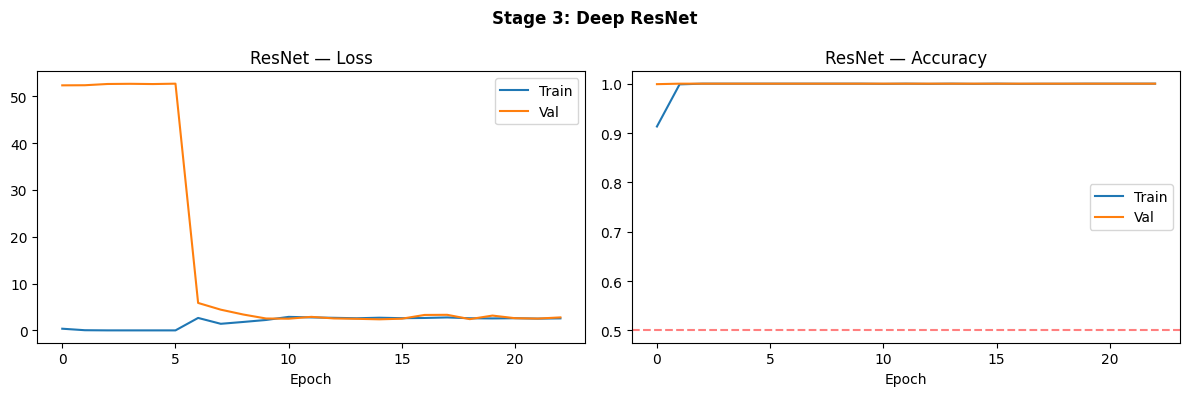

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  STAGE 3: DEEP RESNET
# ══════════════════════════════════════════════════════════════════════════════

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=pad)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.proj  = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride), nn.BatchNorm1d(out_ch)
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        return F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))) + self.proj(x))

class DeepResNet1D(nn.Module):
    def __init__(self, n_det=3):
        super().__init__()
        # Stem heavily reduces the 8192 length to save memory
        self.stem = nn.Sequential(
            nn.Conv1d(n_det, 64, kernel_size=15, stride=4, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2) # Output length: 1024
        )

        self.layer1 = ResBlock1D(64,  128, kernel_size=7, stride=2) # 512
        self.layer2 = ResBlock1D(128, 256, kernel_size=5, stride=2) # 256
        self.layer3 = ResBlock1D(256, 512, kernel_size=3, stride=2) # 128
        self.layer4 = ResBlock1D(512, 512, kernel_size=3, stride=2) # 64

        self.dense = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.cls_out = nn.Linear(64, 1)
        self.prm_out = nn.Linear(64, 2)

    def forward(self, x, mask=None):
        if mask is not None:
            x = x * mask.to(x.device).view(1, -1, 1)
        h = self.stem(x)
        h = self.layer4(self.layer3(self.layer2(self.layer1(h))))
        h = self.dense(h)
        return self.cls_out(h).squeeze(-1), self.prm_out(h)

print("\n--- Training Deep ResNet ---")
resnet = DeepResNet1D(n_det=N_DETECTORS).to(DEVICE)
rn_history, rn_probs, rn_prms, rn_auc, rn_mae1, rn_mae2 = train_model(
    resnet, n_epochs=30, lr=1e-4, model_name="ResNet"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(rn_history['train_loss'], label='Train'); ax1.plot(rn_history['val_loss'], label='Val')
ax1.set_title("ResNet — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(rn_history['train_acc'], label='Train'); ax2.plot(rn_history['val_acc'], label='Val')
ax2.set_title("ResNet — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
ax2.axhline(0.5, color='red', ls='--', alpha=0.5)
plt.suptitle("Stage 3: Deep ResNet", fontweight='bold'); plt.tight_layout(); plt.show()


--- Training Transformer (Masked) ---


/tmp/ipykernel_57/3175316569.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


Transformer Ep  1/30 | train loss=0.6830 acc=0.570 | val loss=52.1974 acc=1.000 | reg_w=0.000 | 23s
Transformer Ep  5/30 | train loss=0.0027 acc=1.000 | val loss=46.8256 acc=1.000 | reg_w=0.000 | 111s
Transformer Ep 10/30 | train loss=2.9027 acc=0.999 | val loss=2.3583 acc=1.000 | reg_w=0.080 | 219s
Transformer Ep 15/30 | train loss=3.4096 acc=1.000 | val loss=2.3063 acc=1.000 | reg_w=0.100 | 331s
Transformer Ep 20/30 | train loss=3.0909 acc=1.000 | val loss=2.2906 acc=1.000 | reg_w=0.100 | 445s
Transformer Ep 25/30 | train loss=3.1838 acc=1.000 | val loss=2.2797 acc=1.000 | reg_w=0.100 | 558s
Transformer Ep 30/30 | train loss=3.0813 acc=1.000 | val loss=2.2829 acc=1.000 | reg_w=0.100 | 670s

Transformer FINAL → AUC=1.0000 | MAE(m1)=5.99 | MAE(m2)=3.89 | 670s total


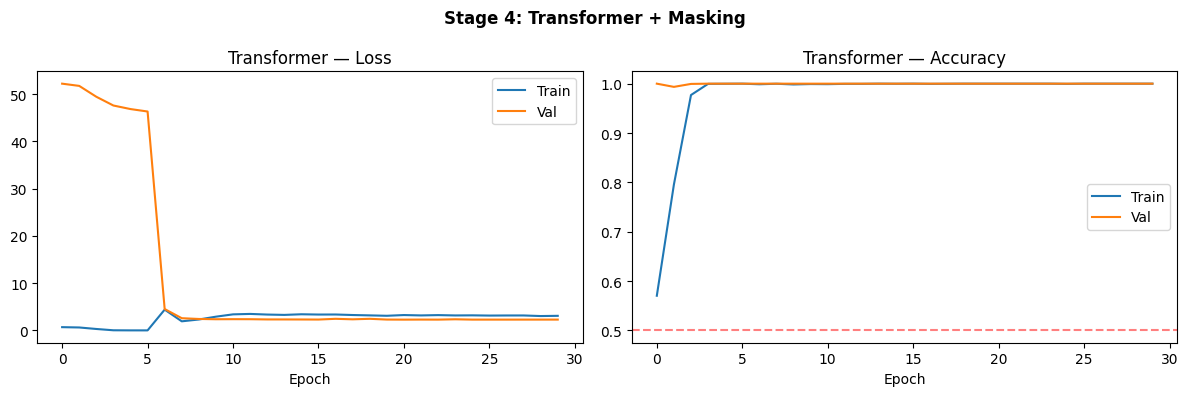

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  STAGE 4: TRANSFORMER + [CLS] TOKEN MASKING
# ══════════════════════════════════════════════════════════════════════════════

class GWTransformer(nn.Module):
    def __init__(self, n_det=3, d_model=128, n_heads=4, n_layers=2):
        super().__init__()
        self.d_model = d_model

        # Tokenizer reduces 8192 -> 128 sequence length
        stride = 8192 // 128  # 64
        self.tokenizer = nn.Sequential(
        nn.Conv1d(n_det, d_model, kernel_size=stride, stride=stride),
        nn.BatchNorm1d(d_model),
        nn.ReLU()
        )

        # [CLS] Token - A learnable parameter prepended to the sequence
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        # Positional Encoding (128 tokens + 1 CLS token = 129)
        pe = torch.zeros(1, 129, d_model)
        pos = torch.arange(129).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[0, :, 0::2] = torch.sin(pos * div)
        pe[0, :, 1::2] = torch.cos(pos * div[:d_model//2])
        self.register_buffer('pe', pe)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=4*d_model, dropout=0.1,
            batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.cls_out = nn.Linear(64, 1)
        self.prm_out = nn.Linear(64, 2)

    def forward(self, x, mask=None):
        if mask is not None:
            x = x * mask.to(x.device).view(1, -1, 1)
        tokens = self.tokenizer(x)            # (B, C, L)
        tokens = tokens.permute(0, 2, 1)      # (B, L, d_model)
        B, L, _ = tokens.shape
        cls_tokens = self.cls_token.expand(B, -1, -1)   # (B, 1, d_model)
        tokens = torch.cat((cls_tokens, tokens), dim=1) # (B, L+1, d_model)
        tokens = tokens + self.pe[:, :L+1, :]
        # Encoder
        enc_out = self.encoder(tokens)
        cls_state = enc_out[:, 0, :]   # (B, d_model)
        cls_state = self.head(cls_state)
        return self.cls_out(cls_state).squeeze(-1), self.prm_out(cls_state)

def random_mask():
    """Drops detectors independently with 30% prob. Keeps at least 1."""
    m = (torch.rand(N_DETECTORS) > 0.3).float()
    if m.sum() == 0: m[0] = 1.0
    return m

print("\n--- Training Transformer (Masked) ---")
transformer = GWTransformer(n_det=N_DETECTORS).to(DEVICE)
tf_history, tf_probs, tf_prms, tf_auc, tf_mae1, tf_mae2 = train_model(
    transformer, n_epochs=30, lr=2e-4, model_name="Transformer", mask_fn=random_mask, patience=10
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(tf_history['train_loss'], label='Train'); ax1.plot(tf_history['val_loss'], label='Val')
ax1.set_title("Transformer — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(tf_history['train_acc'], label='Train'); ax2.plot(tf_history['val_acc'], label='Val')
ax2.set_title("Transformer — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
ax2.axhline(0.5, color='red', ls='--', alpha=0.5)
plt.suptitle("Stage 4: Transformer + Masking", fontweight='bold'); plt.tight_layout(); plt.show()


--- Training Baseline Transformer (No Masking) ---


/tmp/ipykernel_57/3175316569.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


Transformer(no-mask) Ep  1/30 | train loss=0.6662 acc=0.663 | val loss=51.3964 acc=0.930 | reg_w=0.000 | 22s
Transformer(no-mask) Ep  5/30 | train loss=0.0030 acc=1.000 | val loss=43.6122 acc=1.000 | reg_w=0.000 | 113s
Transformer(no-mask) Ep 10/30 | train loss=2.5938 acc=1.000 | val loss=2.6600 acc=1.000 | reg_w=0.080 | 226s
Transformer(no-mask) Ep 15/30 | train loss=3.1925 acc=1.000 | val loss=2.2975 acc=1.000 | reg_w=0.100 | 338s
Transformer(no-mask) Ep 20/30 | train loss=3.0904 acc=1.000 | val loss=2.2834 acc=1.000 | reg_w=0.100 | 450s
Transformer(no-mask) Ep 25/30 | train loss=2.9860 acc=1.000 | val loss=2.2977 acc=1.000 | reg_w=0.100 | 557s
Transformer(no-mask) Ep 30/30 | train loss=3.0788 acc=1.000 | val loss=2.2829 acc=1.000 | reg_w=0.100 | 665s

Transformer(no-mask) FINAL → AUC=1.0000 | MAE(m1)=5.99 | MAE(m2)=3.84 | 666s total

Evaluating both models under masking...
  [masked  ] Full (HLV)           | AUC=1.0000 | Acc=1.000
  [masked  ] Mask V (HL)          | AUC=1.0000 | Acc

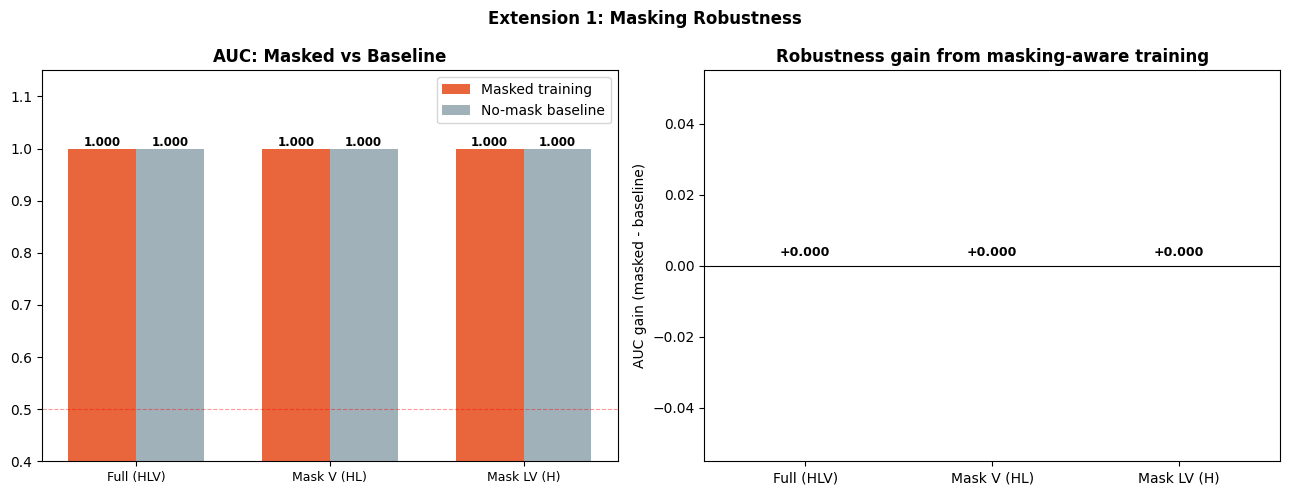

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  EXTENSION 1: MASKING ROBUSTNESS 
# ══════════════════════════════════════════════════════════════════════════════

print("\n--- Training Baseline Transformer (No Masking) ---")
transformer_nomask = GWTransformer(n_det=N_DETECTORS).to(DEVICE)
nm_history, nm_probs, nm_prms, nm_auc, nm_mae1, nm_mae2 = train_model(
    transformer_nomask, n_epochs=30, lr=2e-4, model_name="Transformer(no-mask)", mask_fn=None
)

# ─── Evaluate under all masking configs ───
det_configs = {
    "Full (HLV)":  torch.tensor([1., 1., 1.]),
    "Mask V (HL)": torch.tensor([1., 1., 0.]),
    "Mask LV (H)": torch.tensor([1., 0., 0.]),
}

comparison = {"masked": {}, "no_mask": {}}
print("\nEvaluating both models under masking...")

def evaluate_mask_config(model, config_mask):
    model.eval()
    all_probs, all_yc = [], []
    with torch.no_grad():
        for xb, yc, _ in test_loader:
            xb, yc = xb.to(DEVICE), yc.to(DEVICE).float()
            # Explicitly apply the fixed mask
            cls_out, _ = model(xb, mask=config_mask)
            all_probs.append(cls_out.sigmoid().cpu().numpy())
            all_yc.append(yc.cpu().numpy())
    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_yc)
    acc = ((probs > 0.5).astype(int) == labels.astype(int)).mean()
    auc = roc_auc_score(labels, probs)
    return auc, acc

for label, m_eval in [("masked", transformer), ("no_mask", transformer_nomask)]:
    for cfg, mask in det_configs.items():
        auc, acc = evaluate_mask_config(m_eval, mask)
        comparison[label][cfg] = {"auc": auc, "acc": acc}
        print(f"  [{label:8s}] {cfg:20s} | AUC={auc:.4f} | Acc={acc:.3f}")

# ─── Plotting the Robustness Gap ───
cfg_names = list(det_configs.keys())
masked_aucs = [comparison["masked"][c]["auc"] for c in cfg_names]
nomask_aucs = [comparison["no_mask"][c]["auc"] for c in cfg_names]
gaps = np.array(masked_aucs) - np.array(nomask_aucs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
xp = np.arange(len(cfg_names)); w = 0.35

b1 = axes[0].bar(xp - w/2, masked_aucs, w, label="Masked training", color="#E64A19", alpha=0.85)
b2 = axes[0].bar(xp + w/2, nomask_aucs, w, label="No-mask baseline", color="#90A4AE", alpha=0.85)
for bar, v in list(zip(b1, masked_aucs)) + list(zip(b2, nomask_aucs)):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}", ha='center', fontsize=8.5, fontweight='bold')
axes[0].set_xticks(xp); axes[0].set_xticklabels(cfg_names, fontsize=9)
axes[0].set_ylim(0.4, 1.15); axes[0].set_title("AUC: Masked vs Baseline", fontweight='bold')
axes[0].legend(); axes[0].axhline(0.5, color='red', ls='--', lw=0.8, alpha=0.4)

bar_cols = ["#4CAF50" if g >= 0 else "#F44336" for g in gaps]
bars = axes[1].bar(cfg_names, gaps, color=bar_cols, alpha=0.85)
for bar, g in zip(bars, gaps):
    axes[1].text(bar.get_x() + bar.get_width()/2, g + (0.002 if g >= 0 else -0.008),
                 f"{g:+.3f}", ha='center', va='bottom' if g >= 0 else 'top', fontsize=9, fontweight='bold')
axes[1].axhline(0, color='black', lw=0.8); axes[1].set_ylabel("AUC gain (masked - baseline)")
axes[1].set_title("Robustness gain from masking-aware training", fontweight='bold')
plt.suptitle("Extension 1: Masking Robustness", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

Band             CNN       ResNet    Transformer   N_sig
Low (6-10)       1.000     1.000     1.000         145
Mid (10-15)      1.000     1.000     1.000         179
High (15-20)     1.000     1.000     1.000         176


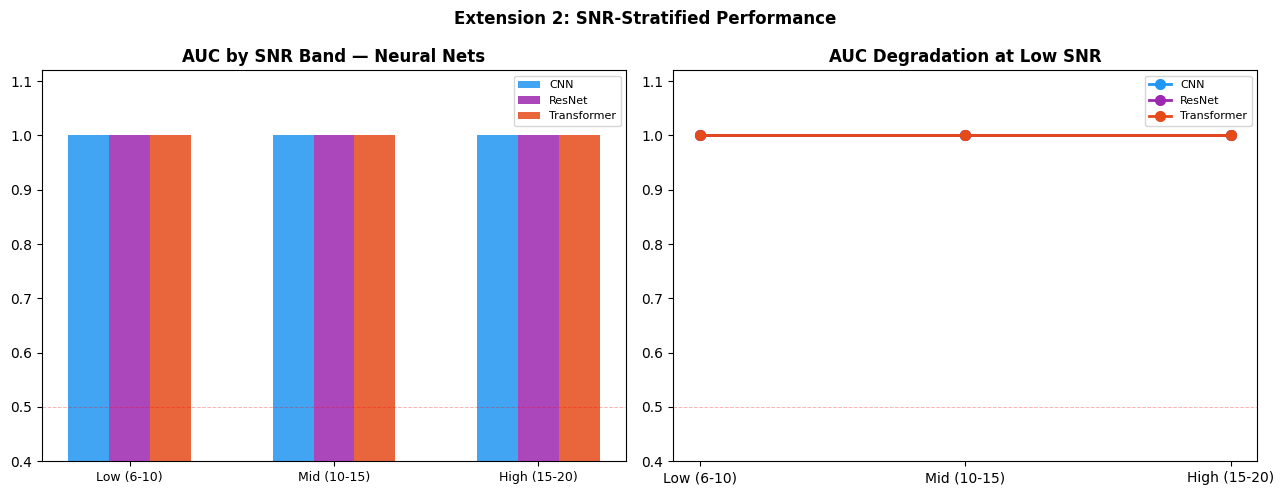

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  EXTENSION 2: SNR-STRATIFIED PERFORMANCE
# ══════════════════════════════════════════════════════════════════════════════

# Re-simulate the test set RNG to grab the exact injected SNRs
rng_snr = np.random.default_rng(42) # Match seed from make_static_test_set
n_test = len(X_test)
snr_test = np.zeros(n_test)

for i in range(n_test):
    is_sig = i % 2 == 0
    for _ in range(N_DETECTORS): rng_snr.standard_normal(N_SAMPLES)
    if is_sig:
        m1, m2 = sorted(rng_snr.uniform(10,50,2), reverse=True)
        snr_test[i] = rng_snr.uniform(6,20)

snr_bands = [("Low (6-10)", 6, 10), ("Mid (10-15)", 10, 15), ("High (15-20)", 15, 20)]
model_scores  = {"CNN": cnn_probs, "ResNet": rn_probs, "Transformer": tf_probs}
model_colors2 = {"CNN": "#2196F3", "ResNet": "#9C27B0", "Transformer": "#E64A19"}
noise_mask = y_test_cls.numpy() == 0
snr_results = {m: {} for m in model_scores}

print(f"{'Band':15s}  {'CNN':8s}  {'ResNet':8s}  {'Transformer':12s}  N_sig")
for bname, lo, hi in snr_bands:
    sig_band  = (y_test_cls.numpy() == 1) & (snr_test >= lo) & (snr_test < hi)
    band_mask = sig_band | noise_mask
    n_sig = int(sig_band.sum())
    if n_sig < 5: continue
    row = []
    for mname, scores in model_scores.items():
        auc = roc_auc_score(y_test_cls.numpy()[band_mask], scores[band_mask])
        snr_results[mname][bname] = auc
        row.append(f"{auc:.3f}")
    print(f"{bname:15s}  {row[0]:8s}  {row[1]:8s}  {row[2]:12s}  {n_sig}")

band_labels = [b[0] for b in snr_bands if b[0] in snr_results["CNN"]]
x = np.arange(len(band_labels)); n_m = 3; wb = 0.2
offsets = np.linspace(-(n_m-1)/2, (n_m-1)/2, n_m) * wb

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (mname, col) in enumerate(model_colors2.items()):
    aucs = [snr_results[mname].get(b, np.nan) for b in band_labels]
    axes[0].bar(x + offsets[i], aucs, wb, label=mname, color=col, alpha=0.85)
    axes[1].plot(band_labels, aucs, 'o-', color=col, lw=2, markersize=7, label=mname)

for ax in axes:
    ax.set_ylim(0.4, 1.12); ax.axhline(0.5, color='red', ls='--', lw=0.7, alpha=0.3); ax.legend(fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(band_labels, fontsize=9)
axes[0].set_title("AUC by SNR Band — Neural Nets", fontweight='bold')
axes[1].set_title("AUC Degradation at Low SNR", fontweight='bold')
plt.suptitle("Extension 2: SNR-Stratified Performance", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  EXTENSION 3: MULTI-EVENT REAL TEST
# ══════════════════════════════════════════════════════════════════════════════

EVENTS = {
    "GW150914": {"gps": 1126259462.4, "detectors": ["H1","L1"], "m1": 35.6, "m2": 30.6, "Mc": 28.3, "type": "BBH"},
    "GW170814": {"gps": 1186741861.5, "detectors": ["H1","L1","V1"], "m1": 30.5, "m2": 25.3, "Mc": 24.1, "type": "BBH (3-det)"},
    "GW170817": {"gps": 1187008882.4, "detectors": ["H1","L1"], "m1": 1.36, "m2": 1.17, "Mc": 1.186, "type": "BNS (Out-of-range)"},
}

def whiten_real_segment(strain, fs_orig, fs_target=8192):
    from math import gcd
    up = int(fs_target)
    dn = int(fs_orig)
    g = gcd(up, dn)
    up //= g
    dn //= g
    s = scipy_signal.resample_poly(strain, up, dn)
    # Remove DC offset
    s = s - np.mean(s)
    n = len(s)
    fs = fs_target
    # ================= BANDPASS =================
    # Better for BBH chirps
    sos = scipy_signal.butter(
        6,
        [20, 500],
        btype='bandpass',
        fs=fs,
        output='sos'
    )
    # zero-phase filtering
    s = scipy_signal.sosfiltfilt(sos, s)
    # ================= PSD / WHITEN =================
    fw, pw = scipy_signal.welch(s,fs=fs,nperseg=min(n // 4, 8192))
    freqs = np.fft.rfftfreq(n, d=1.0/fs)
    pi = np.interp(freqs, fw, pw)
    # numerical stability
    floor = np.percentile(pi, 5)
    pi = np.maximum(pi, floor)
    hf = np.fft.rfft(s)
    sw = np.fft.irfft(hf / np.sqrt(pi), n=n)
    # ================= CENTER CROP =================
    mid = n // 2
    st = max(0, mid - fs // 2)
    seg = sw[st:st + fs]
    # ================= NORMALIZE =================
    rms = np.std(seg)
    if rms > 0:
        seg = seg / rms
    return seg.astype(np.float32)

@torch.no_grad()
def run_all_models_on_event(x_np):
    x = torch.from_numpy(x_np[None]).to(DEVICE)
    results = {}
    for name, model in [("CNN", cnn), ("ResNet", resnet), ("Transformer", transformer)]:
        model.eval()
        cls_o, prm_o = model(x)
        prob = float(cls_o.sigmoid().item())
        m1e = float(np.clip(prm_o[0,0].cpu().item(), 0.5, 150))
        m2e = float(np.clip(prm_o[0,1].cpu().item(), 0.5, 150))
        Mce = (m1e*m2e)**0.6/(m1e+m2e)**0.2
        results[name] = {"prob": prob, "m1": m1e, "m2": m2e, "Mc": Mce}
    return results

event_results, event_sources = {}, {}
for ename, info in EVENTS.items():
    print(f"\n--- {ename} ({info['type']}) ---")

    # Try fetching real data, fallback to synthetic injection if gwpy missing
    x_event = None
    try:
        from gwpy.timeseries import TimeSeries
        segs = []
        for det in ["H1", "L1", "V1"]:
            if det in info["detectors"]:
                ts = TimeSeries.fetch_open_data(det, int(info["gps"])-8, int(info["gps"])+8)
                segs.append(whiten_real_segment(ts.value, float(ts.sample_rate.value)))
            else:
                # Detector offline, inject pure noise
                rng_tmp = np.random.default_rng(hash(ename+det)%2**31)
                v = whiten(generate_colored_noise(N_SAMPLES, FS, rng_tmp)*2.0, FS).astype(np.float32)
                segs.append(v)
        x_event = np.stack(segs, axis=0)
        event_sources[ename] = "Real GWOSC Data"
    except ImportError:
        # Synthetic Injection Fallback
        m1_inj, m2_inj = min(info["m1"], 50.0), min(info["m2"], 50.0)
        if m2_inj < 1.0: m2_inj = 1.0

        segs, rng = [], np.random.default_rng(hash(ename)%2**31)
        for d in range(N_DETECTORS):
            noise = generate_colored_noise(N_SAMPLES, FS, rng)
            chirp = generate_bbh_chirp(m1_inj, m2_inj, N_SAMPLES, FS, snr_target=12.0)
            segs.append(whiten(noise + chirp, FS).astype(np.float32))
        x_event = np.stack(segs, axis=0)
        event_sources[ename] = "Synthetic Injection Fallback (gwpy missing)"

    preds = run_all_models_on_event(x_event)
    event_results[ename] = preds
    print(f"  Source: {event_sources[ename]}")
    print(f"  {'Model':15s}  {'P(sig)':8s}  {'m1':6s}  {'m2':6s}  {'Mc':6s}")
    print(f"  {'Catalog':15s}  {'---':8s}  {info['m1']:6.2f}  {info['m2']:6.2f}  {info['Mc']:6.3f}")
    for mname, r in preds.items():
        print(f"  {mname:15s}  {r['prob']:8.3f}  {r['m1']:6.2f}  {r['m2']:6.2f}  {r['Mc']:6.3f}")


--- GW150914 (BBH) ---
  Source: Synthetic Injection Fallback (gwpy missing)
  Model            P(sig)    m1      m2      Mc    
  Catalog          ---        35.60   30.60  28.300
  CNN                 1.000   33.83   18.61  21.653
  ResNet              1.000   31.20   17.84  20.379
  Transformer         1.000   33.03   18.64  21.428

--- GW170814 (BBH (3-det)) ---
  Source: Synthetic Injection Fallback (gwpy missing)
  Model            P(sig)    m1      m2      Mc    
  Catalog          ---        30.50   25.30  24.100
  CNN                 1.000   33.66   18.56  21.568
  ResNet              1.000   31.06   17.82  20.328
  Transformer         1.000   32.91   18.50  21.306

--- GW170817 (BNS (Out-of-range)) ---
  Source: Synthetic Injection Fallback (gwpy missing)
  Model            P(sig)    m1      m2      Mc    
  Catalog          ---         1.36    1.17   1.186
  CNN                 1.000   33.39   18.37  21.375
  ResNet              1.000   30.95   17.64  20.183
  Transformer  